# CapStone Project!



## Setup

Overview

Load PDFs: Read all PDF files from a specified folder path.
Extract Content: Extract text content from each PDF.
Classify Document: Use a Language Model (LLM) to classify the document as 'Cease & Desist', 'Uncertain', or 'Irrelevant'.
Process Based on Type: Based on the classification, perform different actions:
Cease & Desist: Extract document details (date, name) and store them in a local database (placeholder provided).
Irrelevant: Extract document details and pass them to an archiving agent to write to a flat file (placeholder provided).
Uncertain: Flag for human review.
We'll use langchain_community for PDF loading and langgraph for orchestration. For document classification, we'll use a GoogleGenerativeAI model. Please ensure you have your GOOGLE_API_KEY configured in Colab secrets.

What we're doing: Install required packages for the Colab session.

In [7]:
print("Installing Dependicies")
%pip install -qU langchain_community langchain-google-genai langgraph pypdf langchain-groq requests
print("Dependicies Installed")

Installing Dependicies
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.1/168.1 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.7/333.7 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
Dependicies Installed


What we're doing: Load the GROQ API key from Colab userdata into the environment.

In [8]:
from google.colab import userdata
import os
print("Loading API Keys")
os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')
# Optional for LangSmith Tracking
os.environ["LANGSMITH_API_KEY"] = userdata.get('LANGSMITH_API_KEY')
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_PROJECT"] = "LangChain Quick Start"
print("Loaded API Keys")

Loading API Keys
Loaded API Keys


What we're doing: Downloading the required Libraries

In [9]:
#Installing Dependencies for the process
import os
from typing import List, Literal, Dict, TypedDict
from langgraph.graph import StateGraph, END
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.documents import Document
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
from google.colab import userdata
from pydantic import BaseModel # Import BaseModel
import pandas as pd
import json
import requests

Creating the Input Folder if Folder is not there.

In [10]:


folder_name = "InputPDFFolder"

if not os.path.exists(folder_name):
    os.makedirs(folder_name)
    print(f"Folder '{folder_name}' created successfully.")
else:
    print(f"Folder '{folder_name}' already exists.")

Folder 'InputPDFFolder' already exists.


Downloads the files from the Github Folder where Input files are available.. here downloading will not happen if there is a files already present in the input pdf folder

In [34]:
github_api_url = "https://api.github.com/repos/jayyanar/agentic-ai-training/contents/day5/capstone-project/data/pdfs"
local_folder_path = "InputPDFFolder"

# Create local folder if it doesn't exist (already handled by previous code, but good to ensure)
if not os.path.exists(local_folder_path):
    os.makedirs(local_folder_path)

try:
    response = requests.get(github_api_url)
    response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
    files_data = response.json()

    downloaded_count = 0
    skipped_count = 0

    for item in files_data:
        if item['type'] == 'file' and item['name'].endswith('.pdf'):
            file_name = item['name']
            file_url = item['download_url']
            local_file_path = os.path.join(local_folder_path, file_name)

            if os.path.exists(local_file_path):
                print(f"File '{file_name}' already exists locally. Skipping download.")
                skipped_count += 1
            else:
                print(f"Downloading '{file_name}'...")
                file_content_response = requests.get(file_url)
                file_content_response.raise_for_status()
                with open(local_file_path, 'wb') as f:
                    f.write(file_content_response.content)
                print(f"'{file_name}' downloaded successfully.")
                downloaded_count += 1

    print(f"\n--- Download Summary ---")
    print(f"Total PDF files found: {downloaded_count + skipped_count}")
    print(f"Files downloaded: {downloaded_count}")
    print(f"Files skipped (already existed): {skipped_count}")

except requests.exceptions.RequestException as e:
    print(f"Error fetching data from GitHub: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

'01_copyright_infringement_photography.pdf' downloaded successfully.
'02_trademark_infringement_tech.pdf' downloaded successfully.
File '03_trade_secret_misappropriation.pdf' already exists locally. Skipping download.
'04_defamation_online_review.pdf' downloaded successfully.
'05_patent_infringement_medical_device.pdf' downloaded successfully.
'06_harassment_workplace.pdf' downloaded successfully.
'07_software_license_violation.pdf' downloaded successfully.
'08_non_compete_violation.pdf' downloaded successfully.
'09_copyright_infringement_music.pdf' downloaded successfully.
'10_breach_of_contract_nda.pdf' downloaded successfully.
'LOA2.pdf' downloaded successfully.
'LOA3.pdf' downloaded successfully.
'LOA4.pdf' downloaded successfully.
'LOA5.pdf' downloaded successfully.
'LOA6.pdf' downloaded successfully.
'LOA7.pdf' downloaded successfully.
'LOA8.pdf' downloaded successfully.
'LOA9.pdf' downloaded successfully.
'LoA1.pdf' downloaded successfully.
'bw_doc_1.pdf' downloaded successfully

What we're doing: Downloading the DB Locally and Create the table schema

In [11]:
#Setting up the Database locally
import sqlite3

print("Setup DB Locally Started")
DB_NAME = "document_processing.db"

def setup_database():
    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()

    # Create 'Cease & Desist' table
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS Cease_Desist (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            document_name TEXT NOT NULL,
            date_received TEXT NOT NULL,
            extracted_details TEXT
        )
    """)

    # Create 'Irrelevant' table
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS Irrelevant (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            document_name TEXT NOT NULL,
            date_received TEXT NOT NULL
        )
    """)

    conn.commit()
    conn.close()
    print(f"Database '{DB_NAME}' and tables 'Cease_Desist' and 'Irrelevant' are set up.")

# Call the setup function
setup_database()
print("Setup DB Locally Ended")


Setup DB Locally Started
Database 'document_processing.db' and tables 'Cease_Desist' and 'Irrelevant' are set up.
Setup DB Locally Ended


What we're doing: Initializing the LLM and state Schema

In [45]:
print("Initialize the LLM and State Schema Started")
#llm = ChatGroq(temperature=0, groq_api_key=os.environ.get('GROQ_API_KEY'), model_name="llama-3.3-70b-versatile") # Changed LLM initialization
llm = ChatGroq(temperature=0, groq_api_key=os.environ.get('GROQ_API_KEY'), model_name="qwen/qwen3-32b")

# Define Pydantic model for LLM's structured output
from typing import Union
class ClassificationOutput(BaseModel):
    classification: Literal["Cease & Desist", "Uncertain", "Irrelevant"]
    reason: str
    confidence: Union[float, str]

# Define the graph state
class GraphState(TypedDict):
    folder_path: str
    documents: List[Document]
    classified_documents: List[Dict]
    # Add a field for a single document being processed at a time
    current_document: Document
    document_type: Literal["Cease & Desist", "Uncertain", "Irrelevant", "Processing"]
    document_details: Dict
    classification_reason: str # Added field for classification reason
    confidence_score: float # Added confidence score
    is_human_involved: bool # Added field to track human involvement
print("Initialize the LLM and State Schema Ended")

Initialize the LLM and State Schema Started
Initialize the LLM and State Schema Ended


What we're doing: Defining the 'load_pdf_node' ,'extract_pdf_node' and 'classify_document_node' nodes

Here Classy PDF node will classify the pdf contents based on the confidence score which LLM has returns and then classification reason also returned from the LLM . Both Confidence score and the classification reason will be updated in the final summary table

In [46]:
# --- Node Definitions ---

print("Node Definitaions Started for Load PDF, Extract PDF and Classify the PDF Started")

def load_pdf_node(state: GraphState) -> GraphState:
    """Loads all PDF files from the specified folder path as single documents (concatenating pages)."""
    print("---LOADING PDFs---")
    folder_path = state['folder_path']
    all_documents = []
    for filename in os.listdir(folder_path):
        if filename.endswith('.pdf'):
            filepath = os.path.join(folder_path, filename)
            loader = PyPDFLoader(filepath)
            pages = loader.load() # This returns a list of Document objects, one per page

            # Combine all page contents into a single Document object for the entire PDF
            full_content = "\n\n".join([p.page_content for p in pages])
            # Use the metadata from the first page, or create new metadata
            if pages:
                doc_metadata = pages[0].metadata.copy()
                doc_metadata['source'] = filepath # Ensure source is the file path
                # Optionally add total pages or other relevant info
                doc_metadata['total_pages'] = len(pages)
            else:
                doc_metadata = {'source': filepath, 'total_pages': 0}

            combined_doc = Document(page_content=full_content, metadata=doc_metadata)
            all_documents.append(combined_doc) # Add the single combined document
    return {"documents": all_documents, "document_type": "Processing"}

def extract_pdf_node(state: GraphState) -> GraphState:
    """Extracts content from a single PDF document."""
    print("---EXTRACTING PDF CONTENT---")
    current_doc = state['current_document']
    # Content is already loaded by PyPDFLoader into page_content
    # We can further process or clean it here if needed
    # For now, we assume page_content holds the extracted text
    extracted_content = current_doc.page_content
    print(f"Extracted content from {current_doc.metadata.get('source', 'unknown')[:30]}...")
    # You might want to store extracted_content in the state or directly use it for classification
    return state # No change to state, content is in current_document

def classify_document_node(state: GraphState) -> GraphState:
    """Classifies the document content into predefined categories, provides a reason, and a confidence score."""
    print("---CLASSIFYING DOCUMENT---")
    current_doc = state['current_document']
    content = current_doc.page_content

    # Use with_structured_output to force JSON format
    llm_structured = llm.with_structured_output(ClassificationOutput)

    prompt = f"""Classify the following document content into one of these categories: 'Cease & Desist', 'Uncertain', or 'Irrelevant'.
    Provide a concise reason for the classification and a confidence score (a float between 0.0 and 100.0).

    If it's clearly a legal notice requesting someone to stop an activity, classify as 'Cease & Desist'.
    If it's not a 'Cease & Desist' and not clearly irrelevant, classify as 'Uncertain'.
    If it has no relevant information or is clearly not related to legal or business operations, classify as 'Irrelevant'.

    It is crucial to provide a concise reason or the keyphrase/sentence from the document that led to your classification. If no clear reason is apparent, state 'No specific reason found.'.

    Document content:
    ---
    {content}
    ---

    """

    response = llm_structured.invoke([HumanMessage(content=prompt)])

    # Directly access attributes from the Pydantic object
    classification = response.classification
    reason = response.reason
    try:
        confidence = float(response.confidence) # Explicitly cast to float
    except ValueError:
        print(f"Warning: LLM returned non-numeric confidence: {response.confidence}. Defaulting to 0.0.")
        confidence = 0.0 # Default to 0.0 if conversion fails

    print(f"LLM Structured Response: {response.model_dump()}")

    # Apply confidence threshold logic
    final_doc_type = "Uncertain"
    if "cease & desist" in classification.lower() and confidence > 80:
        final_doc_type = "Cease & Desist"
    elif "irrelevant" in classification.lower() and confidence > 80:
        final_doc_type = "Irrelevant"
    else:
        final_doc_type = "Uncertain" # Default or if confidence is not high enough

    print(f"Parsed Classification: {classification}")
    print(f"Parsed Reason: {reason}")
    print(f"Parsed Confidence: {confidence}")
    print(f"Final Document Type (after threshold): {final_doc_type}")

    return {"document_type": final_doc_type, "classification_reason": reason, "confidence_score": confidence}


print("Node Definitaions Started for Load PDF, Extract PDF and Classify the PDF Ended")

Node Definitaions Started for Load PDF, Extract PDF and Classify the PDF Started
Node Definitaions Started for Load PDF, Extract PDF and Classify the PDF Ended


What we're doing: Defining the process_irrelevant_node and human_in_the_loop node

In [47]:
def process_irrelevant_node(state: GraphState) -> GraphState:
    """Handles 'Irrelevant' documents: extracts details and sends to archiving agent."""
    print("---PROCESSING IRRELEVANT DOCUMENT---")
    current_doc = state['current_document']
    classification_reason = state.get('classification_reason', 'N/A')
    confidence_score = state.get('confidence_score', 0.0) # Get confidence score
    is_human_involved = state.get('is_human_involved', False) # Get human involvement status

    # --- Placeholder for detail extraction ---
    document_name = os.path.basename(current_doc.metadata.get('source', 'unknown_doc.pdf'))

    # Use LLM for structured extraction of date
    prompt_extract_date = f"""From the following document content, extract the primary date on which the document was issued or received.
    Return the date in 'YYYY-MM-DD' format. If no specific date is found, return 'NA'.

    Document content:
    ---
    {current_doc.page_content}
    ---

    Extracted Date (YYYY-MM-DD or NA):"""
    date_response = llm.invoke([HumanMessage(content=prompt_extract_date)])
    date_received = date_response.content.strip()
    if not date_received or date_received.lower() == 'na':
        date_received = "NA" # Ensure it's 'NA' if LLM can't find it

    document_details = {
        "document_name": document_name,
        "date_received": date_received,
        "classification_reason": classification_reason, # Include the classification reason
        "confidence_score": confidence_score, # Include confidence score
        "is_human_involved": is_human_involved # Include human involvement status
    }

    # --- Placeholder for archiving agent call ---
    print(f"Calling archiving agent to write to flat file for: {document_details}")
    insert_irrelevant_document(document_name, date_received)

    # Update state with processed info
    classified_docs = state.get('classified_documents', [])
    classified_docs.append({"type": "Irrelevant", "details": document_details})

    return {"classified_documents": classified_docs, "document_details": document_details}

What we're doing: Defining the functions to load the data into database

In [48]:
print("LoadingFunctios to insert details into table started")

def insert_cease_desist_document(document_name: str, date_received: str, extracted_details: str):
    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    cursor.execute(
        "INSERT INTO Cease_Desist (document_name, date_received, extracted_details) VALUES (?, ?, ?)",
        (document_name, date_received, extracted_details)
    )
    conn.commit()
    conn.close()
    print(f"Inserted '{document_name}' into Cease_Desist table.")

def insert_irrelevant_document(document_name: str, date_received: str):
    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    cursor.execute(
        "INSERT INTO Irrelevant (document_name, date_received) VALUES (?, ?)",
        (document_name, date_received)
    )
    conn.commit()
    conn.close()
    print(f"Inserted '{document_name}' into Irrelevant table.")

print("LoadingFunctios to insert details into table Ended")

LoadingFunctios to insert details into table started
LoadingFunctios to insert details into table Ended


What we're doing: Defining the nodes to process ceasea_desist and irreleavant nodes

In [49]:
def process_cease_desist_node(state: GraphState) -> GraphState:
    """Handles 'Cease & Desist' documents: extracts details and stores in a database."""
    print("---PROCESSING CEASE & DESIST DOCUMENT---")
    current_doc = state['current_document']
    classification_reason = state.get('classification_reason', 'N/A')
    confidence_score = state.get('confidence_score', 0.0) # Get confidence score
    is_human_involved = state.get('is_human_involved', False) # Get human involvement status

    # --- Placeholder for detail extraction ---
    document_name = os.path.basename(current_doc.metadata.get('source', 'unknown_doc.pdf'))

    # Use LLM for structured extraction of date
    prompt_extract_date = f"""From the following document content, extract the primary date on which the document was issued or received.
    Return the date in 'YYYY-MM-DD' format. If no specific date is found, return 'NA'.

    Document content:
    ---
    {current_doc.page_content}
    ---

    Extracted Date (YYYY-MM-DD or NA):"""
    date_response = llm.invoke([HumanMessage(content=prompt_extract_date)])
    date_received = date_response.content.strip()
    if not date_received or date_received.lower() == 'na':
        date_received = "NA" # Ensure it's 'NA' if LLM can't find it

    document_details = {
        "document_name": document_name,
        "date_received": date_received,
        "extracted_content": current_doc.page_content,
        "classification_reason": classification_reason, # Include the classification reason
        "confidence_score": confidence_score, # Include confidence score
        "is_human_involved": is_human_involved # Include human involvement status
    }

    # --- Placeholder for local database storage ---
    print(f"Storing details to local database: {document_details}")
    insert_cease_desist_document(document_name, date_received, current_doc.page_content)

    # Update state with processed info
    classified_docs = state.get('classified_documents', [])
    classified_docs.append({"type": "Cease & Desist", "details": document_details})

    return {"classified_documents": classified_docs, "document_details": document_details}

What we are doing here : Defining the Human in the loop node

In [50]:
def human_in_the_loop_node(state: GraphState) -> GraphState:
    """Handles 'Uncertain' documents: flags for human review."""
    print("---FLAGGING FOR HUMAN REVIEW (UNCERTAIN DOCUMENT)---")
    current_doc = state['current_document']
    classification_reason = state.get('classification_reason', 'N/A')
    confidence_score = state.get('confidence_score', 0.0) # Get confidence score
    document_name = os.path.basename(current_doc.metadata.get('source', 'unknown_doc.pdf'))

    review_details = {
        "document_name": document_name,
        "reason": "Uncertain classification",
        "content_snippet": current_doc.page_content[:500] + "...", # Snippet for review
        "classification_reason": classification_reason, # Include the classification reason
        "confidence_score": confidence_score, # Include confidence score
        "is_human_involved": True # Mark as human involved
    }

    print(f"Presenting to human agent for review: {review_details}")
    # In a real system, this would trigger an alert, add to a queue, etc.

    # Update state with processed info
    classified_docs = state.get('classified_documents', [])
    classified_docs.append({"type": "Uncertain", "details": review_details})

    return {"classified_documents": classified_docs, "document_details": review_details, "is_human_involved": True}

What we are doing here - defining the should continue , userchoice and get next document nodes

In [51]:

def should_continue_processing(state: GraphState) -> str:
    """Determines if there are more documents to process."""
    if state['documents']:
        return "process_next_document"
    else:
        return "no_more_documents"

def UserChoice(state: GraphState) -> str:
    """Determines the user response based on that agent will choose the respective node to process further"""
    print("please review the above documents and choose 1 or 2 \n 1. Cease and Desist Document \n 2. Irreleavant Document")
    choice = input("Enter your choice: ")
    if choice == "1":
        return "CeaseandDesist"
    else:
        return "Irrelavant"

def get_next_document(state: GraphState) -> GraphState:
    """Pops the next document from the list and sets it as current_document."""
    documents = state['documents']
    if documents:
        current_doc = documents.pop(0) # Get and remove the first document
        return {"documents": documents, "current_document": current_doc, "document_type": "Processing"}
    return state # Should not happen if should_continue_processing is correctly used

print("Node Definitaions Ended")

Node Definitaions Ended


What we are doing here - Creating the graph from using the  created nodes and adding the edges

In [52]:
# Define the workflow
workflow = StateGraph(GraphState)

# Define nodes
workflow.add_node("load_pdfs", load_pdf_node)
workflow.add_node("get_next_document", get_next_document)
workflow.add_node("extract_pdf", extract_pdf_node)
workflow.add_node("classify_document", classify_document_node)
workflow.add_node("process_cease_desist", process_cease_desist_node)
workflow.add_node("process_irrelevant", process_irrelevant_node)
workflow.add_node("human_in_the_loop", human_in_the_loop_node)

# Set the entry point
workflow.set_entry_point("load_pdfs")

# Define edges
workflow.add_edge("load_pdfs", "get_next_document")
workflow.add_edge("get_next_document", "extract_pdf")
workflow.add_edge("extract_pdf", "classify_document")

# Define conditional edges based on classification
workflow.add_conditional_edges(
    "classify_document",
    lambda state: state['document_type'],
    {
        "Cease & Desist": "process_cease_desist",
        "Irrelevant": "process_irrelevant",
        "Uncertain": "human_in_the_loop",
    },
)

# After processing each document type, loop back to check for more documents or end
workflow.add_conditional_edges(
    "process_cease_desist",
    should_continue_processing,
    {
        "process_next_document": "get_next_document",
        "no_more_documents": END,
    },
)
workflow.add_conditional_edges(
    "process_irrelevant",
    should_continue_processing,
    {
        "process_next_document": "get_next_document",
        "no_more_documents": END,
    },
)
workflow.add_conditional_edges(
    "human_in_the_loop",
    UserChoice,
    {
        "CeaseandDesist": "process_cease_desist",
        "Irrelavant": "process_irrelevant",
    },
)

# Compile the graph
app = workflow.compile()

print("LangGraph workflow compiled successfully!")

LangGraph workflow compiled successfully!


What we're doing: Display the graph's Structure

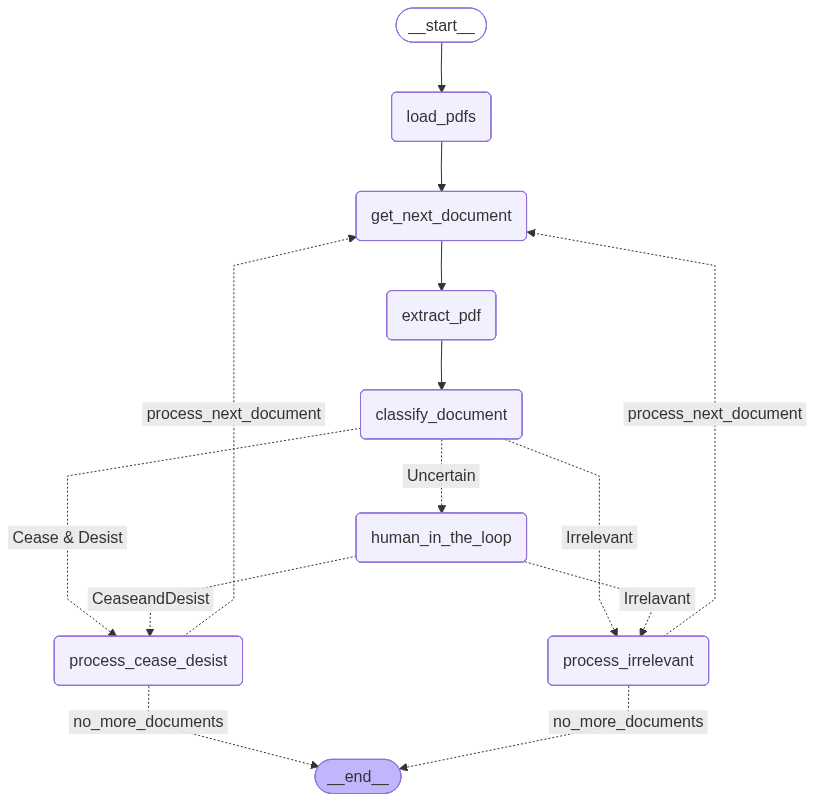

In [20]:
from IPython.display import Image, display

display(Image(app.get_graph(xray=True).draw_mermaid_png()))

What we're doing: Calling the Graph with the input parameter as the folder path

Final Summary table has the Document name , document type , Claassification reason , Confidence Score and then Is Human Invoulved

In [53]:

dummy_folder = "./InputPDFFolder"


initial_state = {"folder_path": folder_name, "documents": [], "classified_documents": [], "is_human_involved": False}

# The graph will iterate through documents automatically until 'no_more_documents'
final_state = app.invoke(initial_state)

print("\n---FINAL CLASSIFICATION SUMMARY---")

# Extract data for the table
table_data = []
for doc_info in final_state['classified_documents']:
    table_data.append({
        "Document Name": doc_info['details']['document_name'],
        "Type": doc_info['type'],
        "Classification Reason": doc_info['details'].get('classification_reason', 'N/A'), # Get reason from details
        "Confidence Score": doc_info['details'].get('confidence_score', 0.0),
        "Is Human Involved": doc_info['details'].get('is_human_involved', False) # Get human involvement status
    })

# Create a pandas DataFrame
df_summary = pd.DataFrame(table_data)

# Format 'Confidence Score' to two decimal places
df_summary['Confidence Score'] = df_summary['Confidence Score'].apply(lambda x: f"{x:.2f}")

# Display the DataFrame without the index using styling for better appearance
display(df_summary.style.hide(axis="index"))

---LOADING PDFs---
---EXTRACTING PDF CONTENT---
Extracted content from InputPDFFolder/notice_5.pdf...
---CLASSIFYING DOCUMENT---
LLM Structured Response: {'classification': 'Irrelevant', 'reason': 'The document content is entirely empty with no text or information provided.', 'confidence': 100.0}
Parsed Classification: Irrelevant
Parsed Reason: The document content is entirely empty with no text or information provided.
Parsed Confidence: 100.0
Final Document Type (after threshold): Irrelevant
---PROCESSING IRRELEVANT DOCUMENT---
Calling archiving agent to write to flat file for: {'document_name': 'notice_5.pdf', 'date_received': '<think>\nOkay, let\'s see. The user wants me to extract the primary date from the document content provided. The document content is just a bunch of dashes and a line with "Document content:" followed by more dashes. There\'s no actual text or dates mentioned here.\n\nHmm, so I need to check if there\'s any date in there. The example given in the problem show

Document Name,Type,Classification Reason,Confidence Score,Is Human Involved
notice_5.pdf,Irrelevant,The document content is entirely empty with no text or information provided.,100.00,False
notice_2.pdf,Irrelevant,The document content is entirely empty with no text or information provided.,100.00,False
LOA8.pdf,Cease & Desist,The document explicitly states: 'formally instruct all parties to cease and desist from contacting me (us) by any mode of communication' which directly matches the 'Cease & Desist' category criteria.,95.00,False
bw_doc_3.pdf,Irrelevant,The document content is entirely empty with no text or information provided.,100.00,False
notice_3.pdf,Irrelevant,The document content is entirely empty with no text or information provided.,100.00,False
02_trademark_infringement_tech.pdf,Cease & Desist,"The document explicitly states 'This letter constitutes a formal demand that you and/or your organization immediately cease and desist all unlawful activity...' and outlines specific legal demands under trademark infringement claims, including requirements to stop using the 'NovaCORE' mark, transfer domains, and destroy infringing materials.",98.50,False
05_patent_infringement_medical_device.pdf,Cease & Desist,"The document explicitly states 'CEASE AND DESIST LETTER' in the header and contains formal demands requiring the recipient to stop patent-infringing activities, including ceasing product manufacture/sales, recalling devices, and entering licensing agreements. The legal basis (35 U.S.C. §§ 271, 281, 283, 284) and specific patent numbers cited further confirm this classification.",95.00,False
LOA7.pdf,Cease & Desist,"The document explicitly contains the instruction 'cesar y desistir de contactarme (nos) por cualquier medio de comunicaci6n' (cease and desist from contacting me/us by any means of communication), which directly matches the 'Cease & Desist' category criteria.",95.00,False
LOA2.pdf,Cease & Desist,"The document explicitly states 'Cease and desist all communications regarding this account' and authorizes the attorney to handle all communications, which is a clear legal directive to stop contact.",95.00,False
01_copyright_infringement_photography.pdf,Cease & Desist,"The document explicitly states 'formal demand that you and/or your organization immediately cease and desist all unlawful activity' regarding unauthorized use of copyrighted photographs, with specific legal demands and consequences for non-compliance.",99.50,False


LangChain Sample Screenshot for tracing

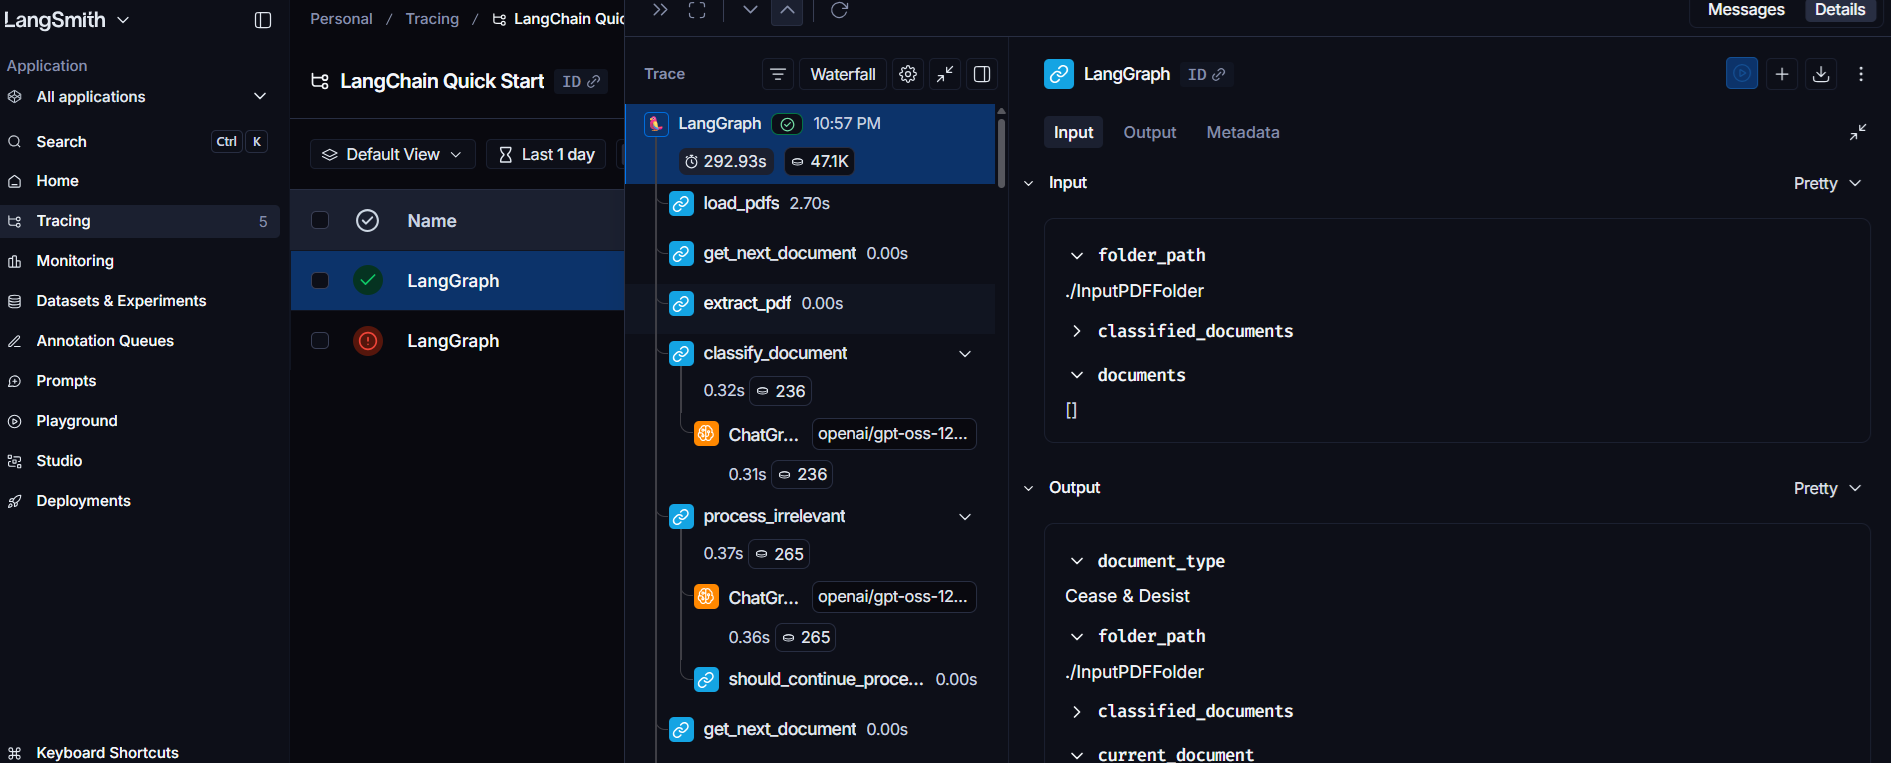